<a href="https://colab.research.google.com/github/vishnuvs0712-maker/Machine-Learning-codes/blob/main/Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

In [2]:
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1],
    [0.2, 0.2],
    [0.2, 0.8],
    [0.8, 0.2],
    [0.8, 0.8]
])

y = np.array([
    0,
    0,
    0,
    1,
    0,
    0,
    0,
    1
])

print("Input data:")
print(X)

print("\nOutput:")
print(y)

Input data:
[[0.  0. ]
 [0.  1. ]
 [1.  0. ]
 [1.  1. ]
 [0.2 0.2]
 [0.2 0.8]
 [0.8 0.2]
 [0.8 0.8]]

Output:
[0 0 0 1 0 0 0 1]


In [3]:
low_lr_model = MLPClassifier(
    hidden_layer_sizes=(4,),
    activation='relu',
    solver='sgd',
    learning_rate_init=0.001,
    max_iter=5000,
    random_state=42,
    tol=1e-8
)

low_lr_model.fit(X, y)

/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(4,), max_iter=5000, random_state=42,
              solver='sgd', tol=1e-08)

Check the low-learning-rate result

In [4]:
low_prediction = low_lr_model.predict(X)

low_accuracy = accuracy_score(y, low_prediction)

print("Actual Output:")
print(y)

print("\nPredicted Output:")
print(low_prediction)

print("\nAccuracy:", low_accuracy)

print("Number of Iterations:", low_lr_model.n_iter_)

print("Final Loss:", low_lr_model.loss_)

Actual Output:
[0 0 0 1 0 0 0 1]

Predicted Output:
[0 0 0 1 0 0 0 1]

Accuracy: 1.0
Number of Iterations: 5000
Final Loss: 0.14618198998381593


neural network with a high learning rate

In [5]:
high_lr_model = MLPClassifier(
    hidden_layer_sizes=(4,),
    activation='relu',
    solver='sgd',
    learning_rate_init=1.0,
    max_iter=5000,
    random_state=42,
    tol=1e-8
)

high_lr_model.fit(X, y)

MLPClassifier(hidden_layer_sizes=(4,), learning_rate_init=1.0, max_iter=5000,
              random_state=42, solver='sgd', tol=1e-08)

Check the high-learning-rate result

In [6]:
high_prediction = high_lr_model.predict(X)

high_accuracy = accuracy_score(y, high_prediction)

print("Actual Output:")
print(y)

print("\nPredicted Output:")
print(high_prediction)

print("\nAccuracy:", high_accuracy)

print("Number of Iterations:", high_lr_model.n_iter_)

print("Final Loss:", high_lr_model.loss_)

Actual Output:
[0 0 0 1 0 0 0 1]

Predicted Output:
[0 0 0 1 0 0 0 1]

Accuracy: 1.0
Number of Iterations: 3690
Final Loss: 0.0008232393208220303


Compare both results

In [7]:
print("LOW LEARNING RATE")
print("Learning Rate = 0.001")
print("Accuracy =", low_accuracy)
print("Iterations =", low_lr_model.n_iter_)
print("Final Loss =", low_lr_model.loss_)

print("\n-------------------------\n")

print("HIGH LEARNING RATE")
print("Learning Rate = 1.0")
print("Accuracy =", high_accuracy)
print("Iterations =", high_lr_model.n_iter_)
print("Final Loss =", high_lr_model.loss_)

LOW LEARNING RATE
Learning Rate = 0.001
Accuracy = 1.0
Iterations = 5000
Final Loss = 0.14618198998381593

-------------------------

HIGH LEARNING RATE
Learning Rate = 1.0
Accuracy = 1.0
Iterations = 3690
Final Loss = 0.0008232393208220303


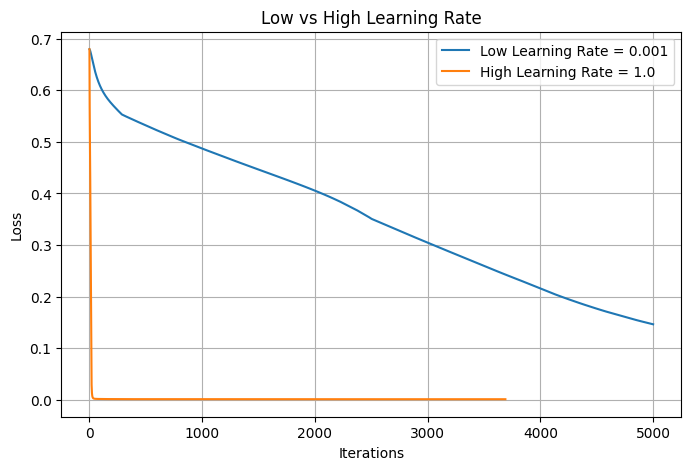

In [8]:
plt.figure(figsize=(8, 5))

plt.plot(
    low_lr_model.loss_curve_,
    label="Low Learning Rate = 0.001"
)

plt.plot(
    high_lr_model.loss_curve_,
    label="High Learning Rate = 1.0"
)

plt.xlabel("Iterations")
plt.ylabel("Loss")

plt.title("Low vs High Learning Rate")

plt.legend()
plt.grid()

plt.show()

PART 2: IMPLEMENTATION OF AND, OR AND XOR GATES USING PERCEPTRON

In [9]:
import numpy as np

In [10]:
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

print("Input combinations:")
print(X)

Input combinations:
[[0 0]
 [0 1]
 [1 0]
 [1 1]]


In [11]:
def step_function(x):
    if x >= 0:
        return 1
    else:
        return 0

Perceptron Function

In [12]:
def perceptron(X, weights, bias):
    outputs = []

    for x in X:
        z = np.dot(x, weights) + bias
        y = step_function(z)
        outputs.append(y)

    return outputs

AND weights and bias

In [13]:
and_weights = np.array([1, 1])
and_bias = -1.5

and_output = perceptron(
    X,
    and_weights,
    and_bias
)

print("AND Gate Output:")
print(and_output)

AND Gate Output:
[0, 0, 0, 1]


In [14]:
print("AND Gate Calculations")
print("----------------------")

for x in X:
    z = np.dot(x, and_weights) + and_bias
    y = step_function(z)

    print(
        "Input:", x,
        "Weighted Sum =", z,
        "Output =", y
    )

AND Gate Calculations
----------------------
Input: [0 0] Weighted Sum = -1.5 Output = 0
Input: [0 1] Weighted Sum = -0.5 Output = 0
Input: [1 0] Weighted Sum = -0.5 Output = 0
Input: [1 1] Weighted Sum = 0.5 Output = 1


OR GATE

In [15]:
or_weights = np.array([1, 1])
or_bias = -0.5

or_output = perceptron(
    X,
    or_weights,
    or_bias
)

print("OR Gate Output:")
print(or_output)

OR Gate Output:
[0, 1, 1, 1]


In [16]:
print("OR Gate Calculations")
print("---------------------")

for x in X:
    z = np.dot(x, or_weights) + or_bias
    y = step_function(z)

    print(
        "Input:", x,
        "Weighted Sum =", z,
        "Output =", y
    )

OR Gate Calculations
---------------------
Input: [0 0] Weighted Sum = -0.5 Output = 0
Input: [0 1] Weighted Sum = 0.5 Output = 1
Input: [1 0] Weighted Sum = 0.5 Output = 1
Input: [1 1] Weighted Sum = 1.5 Output = 1


XOR using one perceptron

In [17]:
xor_expected = np.array([0, 1, 1, 0])

print("XOR Expected Output:")
print(xor_expected)

XOR Expected Output:
[0 1 1 0]


single perceptron for XOR

In [18]:
xor_weights = np.array([1, 1])
xor_bias = -0.5

xor_single_output = perceptron(
    X,
    xor_weights,
    xor_bias
)

print("XOR using Single-Layer Perceptron:")
print(xor_single_output)

print("\nExpected XOR Output:")
print(xor_expected)

XOR using Single-Layer Perceptron:
[0, 1, 1, 1]

Expected XOR Output:
[0 1 1 0]


Multi-Layer XOR Function

In [19]:
def xor_mlp(x1, x2):

    # Hidden neuron 1 performs OR
    h1 = step_function(x1 + x2 - 0.5)

    # Hidden neuron 2 performs AND
    h2 = step_function(x1 + x2 - 1.5)

    # Output neuron performs AND(H1, NOT(H2))
    y = step_function(h1 - 2*h2 - 0.5)

    return h1, h2, y

Test the Multi-Layer XOR

In [20]:
print("XOR using Multi-Layer Perceptron")
print("---------------------------------")

for x1, x2 in X:

    h1, h2, y = xor_mlp(x1, x2)

    print(
        "Input:", x1, x2,
        "H1:", h1,
        "H2:", h2,
        "Output:", y
    )

XOR using Multi-Layer Perceptron
---------------------------------
Input: 0 0 H1: 0 H2: 0 Output: 0
Input: 0 1 H1: 1 H2: 0 Output: 1
Input: 1 0 H1: 1 H2: 0 Output: 1
Input: 1 1 H1: 1 H2: 1 Output: 0


Final comparison table

In [21]:
print("FINAL COMPARISON")
print("================")

print("AND Gate:")
print("Expected :", [0, 0, 0, 1])
print("Output   :", and_output)

print("\nOR Gate:")
print("Expected :", [0, 1, 1, 1])
print("Output   :", or_output)

print("\nXOR Gate - Single Layer:")
print("Expected :", [0, 1, 1, 0])
print("Output   :", xor_single_output)

xor_mlp_output = []

for x1, x2 in X:
    h1, h2, y = xor_mlp(x1, x2)
    xor_mlp_output.append(y)

print("\nXOR Gate - Multi Layer:")
print("Expected :", [0, 1, 1, 0])
print("Output   :", xor_mlp_output)

FINAL COMPARISON
AND Gate:
Expected : [0, 0, 0, 1]
Output   : [0, 0, 0, 1]

OR Gate:
Expected : [0, 1, 1, 1]
Output   : [0, 1, 1, 1]

XOR Gate - Single Layer:
Expected : [0, 1, 1, 0]
Output   : [0, 1, 1, 1]

XOR Gate - Multi Layer:
Expected : [0, 1, 1, 0]
Output   : [0, 1, 1, 0]
